In [1]:
from google.colab import files
uploaded = files.upload()

Saving cirrhosis.csv to cirrhosis.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('cirrhosis.csv')

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
df.shape

(418, 20)

In [4]:
df.columns.tolist()

['ID',
 'N_Days',
 'Status',
 'Drug',
 'Age',
 'Sex',
 'Ascites',
 'Hepatomegaly',
 'Spiders',
 'Edema',
 'Bilirubin',
 'Cholesterol',
 'Albumin',
 'Copper',
 'Alk_Phos',
 'SGOT',
 'Tryglicerides',
 'Platelets',
 'Prothrombin',
 'Stage']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [6]:
df['Status'].value_counts()

,count
Status,
C,232
D,161
CL,25


In [7]:
df['death'] = np.where(df['Status'] == 'D', 1, 0)

df[['Status', 'death']].head(10)

,Status,death
0,D,1
1,C,0
2,D,1
3,D,1
4,CL,0
5,D,1
6,C,0
7,D,1
8,D,1
9,D,1


In [8]:
df['death'].value_counts()

,count
death,
0,257
1,161


In [9]:
pd.crosstab(df['Status'], df['death'])

death,0,1
Status,,
C,232,0
CL,25,0
D,0,161


In [10]:
df['Age_years'] = (df['Age'] / 365.25).round(1)

df[['Age', 'Age_years']].head()

,Age,Age_years
0,21464,58.8
1,20617,56.4
2,25594,70.1
3,19994,54.7
4,13918,38.1


In [11]:
df['Age_years'].describe()

,Age_years
count,418.000000
mean,50.744019
std,10.445328
min,26.300000
25%,42.850000
50%,51.000000
75%,58.275000
max,78.400000


In [12]:
df.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [13]:
missing_table = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().sum() / len(df) * 100
}).sort_values(by='missing_count', ascending=False)

missing_table

,column,missing_count,missing_percent
Tryglicerides,Tryglicerides,136,32.535885
Cholesterol,Cholesterol,134,32.057416
Copper,Copper,108,25.837321
Ascites,Ascites,106,25.358852
Drug,Drug,106,25.358852
Spiders,Spiders,106,25.358852
Alk_Phos,Alk_Phos,106,25.358852
SGOT,SGOT,106,25.358852
Hepatomegaly,Hepatomegaly,106,25.358852
Platelets,Platelets,11,2.631579


In [14]:
lab_features = [
    'Bilirubin',
    'Cholesterol',
    'Albumin',
    'Copper',
    'Alk_Phos',
    'SGOT',
    'Tryglicerides',
    'Platelets',
    'Prothrombin'
]

clinical_features = [
    'Ascites',
    'Hepatomegaly',
    'Spiders',
    'Edema'
]

demographic_features = [
    'Age_years',
    'Sex'
]

treatment_features = [
    'Drug'
]

severity_features = [
    'Stage'
]

print("Lab features:")
print(lab_features)

print("\nClinical features:")
print(clinical_features)

print("\nDemographic features:")
print(demographic_features)

print("\nTreatment features:")
print(treatment_features)

print("\nSeverity features:")
print(severity_features)

Lab features:
['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

Clinical features:
['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Demographic features:
['Age_years', 'Sex']

Treatment features:
['Drug']

Severity features:
['Stage']


In [15]:
features_lab_only = lab_features

features_clinical_only = clinical_features

features_lab_clinical = lab_features + clinical_features

features_full = (
    demographic_features
    + treatment_features
    + clinical_features
    + lab_features
    + severity_features
)

print("Feature set 1: Lab-only")
print(features_lab_only)

print("\nFeature set 2: Clinical-only")
print(features_clinical_only)

print("\nFeature set 3: Lab + Clinical")
print(features_lab_clinical)

print("\nFeature set 4: Full model")
print(features_full)

Feature set 1: Lab-only
['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

Feature set 2: Clinical-only
['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Feature set 3: Lab + Clinical
['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Feature set 4: Full model
['Age_years', 'Sex', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [16]:
X = df[features_full].copy()
y = df['death'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (418, 17)
y shape: (418,)


,Age_years,Sex,Drug,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,58.8,F,D-penicillamine,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,56.4,F,D-penicillamine,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,70.1,M,D-penicillamine,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,54.7,F,D-penicillamine,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,38.1,F,Placebo,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [17]:
X.isnull().sum().sort_values(ascending=False)

,0
Tryglicerides,136
Cholesterol,134
Copper,108
Alk_Phos,106
Drug,106
Spiders,106
SGOT,106
Hepatomegaly,106
Ascites,106
Platelets,11


In [18]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

X[categorical_cols] = X[categorical_cols].fillna('Unknown')

print("\nMissing values after filling categorical columns:")
print(X[categorical_cols].isnull().sum())

Categorical columns:
['Sex', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Missing values after filling categorical columns:
Sex             0
Drug            0
Ascites         0
Hepatomegaly    0
Spiders         0
Edema           0
dtype: int64


In [19]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

for col in numeric_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)

print("\nMissing values after filling numeric columns:")
print(X[numeric_cols].isnull().sum())

Numeric columns:
['Age_years', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

Missing values after filling numeric columns:
Age_years        0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


In [20]:
X.isnull().sum().sum()

np.int64(0)

In [21]:
X.head()

,Age_years,Sex,Drug,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,58.8,F,D-penicillamine,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,56.4,F,D-penicillamine,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,70.1,M,D-penicillamine,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,54.7,F,D-penicillamine,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,38.1,F,Placebo,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [22]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

X_encoded.head()

Before encoding: (418, 17)
After encoding: (418, 22)


,Age_years,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,...,Drug_Placebo,Drug_Unknown,Ascites_Unknown,Ascites_Y,Hepatomegaly_Unknown,Hepatomegaly_Y,Spiders_Unknown,Spiders_Y,Edema_S,Edema_Y
0,58.8,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,...,False,False,False,True,False,True,False,True,False,True
1,56.4,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,...,False,False,False,False,False,True,False,True,False,False
2,70.1,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,...,False,False,False,False,False,False,False,False,True,False
3,54.7,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,...,False,False,False,False,False,True,False,True,True,False
4,38.1,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,...,True,False,False,False,False,True,False,True,False,False


In [23]:
print("Input data shape:", X_encoded.shape)
print("Outcome shape:", y.shape)

print("\nOutcome distribution:")
print(y.value_counts())

print("\nOutcome percentage:")
print(y.value_counts(normalize=True) * 100)

Input data shape: (418, 22)
Outcome shape: (418,)

Outcome distribution:
death
0    257
1    161
Name: count, dtype: int64

Outcome percentage:
death
0    61.483254
1    38.516746
Name: proportion, dtype: float64


In [24]:
# Create a new dataframe for feature engineering
df_fe = df.copy()

# 1. Albumin-to-bilirubin ratio
# Add a very small number to avoid division by zero
df_fe['Albumin_Bilirubin_Ratio'] = df_fe['Albumin'] / (df_fe['Bilirubin'] + 1e-6)

# 2. High bilirubin flag
# Bilirubin > 1.2 mg/dL is commonly considered elevated
df_fe['High_Bilirubin'] = np.where(df_fe['Bilirubin'] > 1.2, 1, 0)

# 3. Low albumin flag
# Albumin < 3.5 g/dL is commonly considered low
df_fe['Low_Albumin'] = np.where(df_fe['Albumin'] < 3.5, 1, 0)

# 4. High prothrombin flag
# Here we use >12 seconds as a simple abnormal threshold
df_fe['High_Prothrombin'] = np.where(df_fe['Prothrombin'] > 12, 1, 0)

# 5. Low platelet flag
# Platelets <150 is commonly considered low
df_fe['Low_Platelets'] = np.where(df_fe['Platelets'] < 150, 1, 0)

# 6. Clinical complication count
# First convert clinical signs into 0/1
df_fe['Ascites_Y'] = np.where(df_fe['Ascites'] == 'Y', 1, 0)
df_fe['Hepatomegaly_Y'] = np.where(df_fe['Hepatomegaly'] == 'Y', 1, 0)
df_fe['Spiders_Y'] = np.where(df_fe['Spiders'] == 'Y', 1, 0)
df_fe['Edema_abnormal'] = np.where(df_fe['Edema'].isin(['S', 'Y']), 1, 0)

# Sum the number of clinical complications
df_fe['Complication_Count'] = (
    df_fe['Ascites_Y']
    + df_fe['Hepatomegaly_Y']
    + df_fe['Spiders_Y']
    + df_fe['Edema_abnormal']
)

# Show new features
df_fe[
    [
        'Bilirubin',
        'Albumin',
        'Albumin_Bilirubin_Ratio',
        'High_Bilirubin',
        'Low_Albumin',
        'Prothrombin',
        'High_Prothrombin',
        'Platelets',
        'Low_Platelets',
        'Ascites',
        'Hepatomegaly',
        'Spiders',
        'Edema',
        'Complication_Count'
    ]
].head(10)

,Bilirubin,Albumin,Albumin_Bilirubin_Ratio,High_Bilirubin,Low_Albumin,Prothrombin,High_Prothrombin,Platelets,Low_Platelets,Ascites,Hepatomegaly,Spiders,Edema,Complication_Count
0,14.5,2.60,0.179310,1,1,12.2,1,190.0,0,Y,Y,Y,Y,4
1,1.1,4.14,3.763633,0,0,10.6,0,221.0,0,N,Y,Y,N,2
2,1.4,3.48,2.485713,1,1,12.0,0,151.0,0,N,N,N,S,1
3,1.8,2.54,1.411110,1,1,10.3,0,183.0,0,N,Y,Y,S,3
4,3.4,3.53,1.038235,1,0,10.9,0,136.0,1,N,Y,Y,N,2
5,0.8,3.98,4.974994,0,0,11.0,0,NaN,0,N,Y,N,N,1
6,1.0,4.09,4.089996,0,0,9.7,0,204.0,0,N,Y,N,N,1
7,0.3,4.00,13.333289,0,0,11.0,0,373.0,0,N,N,N,N,0
8,3.2,3.08,0.962500,1,1,11.0,0,251.0,0,N,N,Y,N,1
9,12.6,2.74,0.217460,1,1,11.5,0,302.0,0,Y,N,Y,Y,3


In [25]:
new_features = [
    'Albumin_Bilirubin_Ratio',
    'High_Bilirubin',
    'Low_Albumin',
    'High_Prothrombin',
    'Low_Platelets',
    'Complication_Count'
]

df_fe.groupby('death')[new_features].mean()

,Albumin_Bilirubin_Ratio,High_Bilirubin,Low_Albumin,High_Prothrombin,Low_Platelets,Complication_Count
death,,,,,,
0,3.874076,0.385214,0.377432,0.027237,0.097276,0.505837
1,1.725434,0.807453,0.583851,0.180124,0.211180,1.291925


In [26]:
engineered_features = [
    'Albumin_Bilirubin_Ratio',
    'High_Bilirubin',
    'Low_Albumin',
    'High_Prothrombin',
    'Low_Platelets',
    'Complication_Count'
]

features_full_fe = features_full + engineered_features

print("Original full features:", len(features_full))
print("Full features with engineered features:", len(features_full_fe))

print(features_full_fe)

Original full features: 17
Full features with engineered features: 23
['Age_years', 'Sex', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Albumin_Bilirubin_Ratio', 'High_Bilirubin', 'Low_Albumin', 'High_Prothrombin', 'Low_Platelets', 'Complication_Count']


In [27]:
X_fe = df_fe[features_full_fe].copy()
y = df_fe['death'].copy()

print("X_fe shape before cleaning:", X_fe.shape)

X_fe.head()

X_fe shape before cleaning: (418, 23)


,Age_years,Sex,Drug,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,...,Tryglicerides,Platelets,Prothrombin,Stage,Albumin_Bilirubin_Ratio,High_Bilirubin,Low_Albumin,High_Prothrombin,Low_Platelets,Complication_Count
0,58.8,F,D-penicillamine,Y,Y,Y,Y,14.5,261.0,2.60,...,172.0,190.0,12.2,4.0,0.179310,1,1,1,0,4
1,56.4,F,D-penicillamine,N,Y,Y,N,1.1,302.0,4.14,...,88.0,221.0,10.6,3.0,3.763633,0,0,0,0,2
2,70.1,M,D-penicillamine,N,N,N,S,1.4,176.0,3.48,...,55.0,151.0,12.0,4.0,2.485713,1,1,0,0,1
3,54.7,F,D-penicillamine,N,Y,Y,S,1.8,244.0,2.54,...,92.0,183.0,10.3,4.0,1.411110,1,1,0,0,3
4,38.1,F,Placebo,N,Y,Y,N,3.4,279.0,3.53,...,72.0,136.0,10.9,3.0,1.038235,1,0,0,1,2


In [28]:
# Fill missing categorical values with Unknown
categorical_cols_fe = X_fe.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols_fe)

X_fe[categorical_cols_fe] = X_fe[categorical_cols_fe].fillna('Unknown')

# Fill missing numeric values with median
numeric_cols_fe = X_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nNumeric columns:")
print(numeric_cols_fe)

for col in numeric_cols_fe:
    median_value = X_fe[col].median()
    X_fe[col] = X_fe[col].fillna(median_value)

# Check missing values
print("\nTotal missing values after cleaning:")
print(X_fe.isnull().sum().sum())

Categorical columns:
['Sex', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Numeric columns:
['Age_years', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Albumin_Bilirubin_Ratio', 'High_Bilirubin', 'Low_Albumin', 'High_Prothrombin', 'Low_Platelets', 'Complication_Count']

Total missing values after cleaning:
0


In [29]:
X_fe_encoded = pd.get_dummies(X_fe, drop_first=True)

print("Before encoding:", X_fe.shape)
print("After encoding:", X_fe_encoded.shape)

X_fe_encoded.head()

Before encoding: (418, 23)
After encoding: (418, 28)


,Age_years,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,...,Drug_Placebo,Drug_Unknown,Ascites_Unknown,Ascites_Y,Hepatomegaly_Unknown,Hepatomegaly_Y,Spiders_Unknown,Spiders_Y,Edema_S,Edema_Y
0,58.8,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,...,False,False,False,True,False,True,False,True,False,True
1,56.4,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,...,False,False,False,False,False,True,False,True,False,False
2,70.1,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,...,False,False,False,False,False,False,False,False,True,False
3,54.7,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,...,False,False,False,False,False,True,False,True,True,False
4,38.1,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,...,True,False,False,False,False,True,False,True,False,False


In [30]:
print("Final input shape:", X_fe_encoded.shape)
print("Final outcome shape:", y.shape)

print("\nOutcome distribution:")
print(y.value_counts())

print("\nAny missing values left?")
print(X_fe_encoded.isnull().sum().sum())

Final input shape: (418, 28)
Final outcome shape: (418,)

Outcome distribution:
death
0    257
1    161
Name: count, dtype: int64

Any missing values left?
0


In [31]:
# Install xgboost if needed
!pip install xgboost -q

# Basic libraries
import pandas as pd
import numpy as np

# Machine learning tools
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score

# XGBoost
from xgboost import XGBClassifier

In [32]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
}

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "AUROC": "roc_auc",
    "AUPRC": "average_precision",
    "Accuracy": "accuracy",
    "Sensitivity": "recall",
    "F1": "f1"
}

In [34]:
results = []

for model_name, model in models.items():
    cv_result = cross_validate(
        model,
        X_fe_encoded,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Model": model_name,
        "AUROC_mean": cv_result["test_AUROC"].mean(),
        "AUROC_sd": cv_result["test_AUROC"].std(),
        "AUPRC_mean": cv_result["test_AUPRC"].mean(),
        "AUPRC_sd": cv_result["test_AUPRC"].std(),
        "Accuracy_mean": cv_result["test_Accuracy"].mean(),
        "Sensitivity_mean": cv_result["test_Sensitivity"].mean(),
        "F1_mean": cv_result["test_F1"].mean()
    })

results_df = pd.DataFrame(results)

results_df

,Model,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
0,Logistic Regression,0.831806,0.029238,0.764390,0.037166,0.770166,0.732576,0.704502
1,Random Forest,0.826718,0.050807,0.772006,0.065262,0.779719,0.639015,0.687367
2,XGBoost,0.831935,0.044378,0.779672,0.057225,0.767814,0.657576,0.683012


In [35]:
results_df_rounded = results_df.copy()

numeric_columns = results_df_rounded.select_dtypes(include=['float64']).columns

results_df_rounded[numeric_columns] = results_df_rounded[numeric_columns].round(3)

results_df_rounded

,Model,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
0,Logistic Regression,0.832,0.029,0.764,0.037,0.770,0.733,0.705
1,Random Forest,0.827,0.051,0.772,0.065,0.780,0.639,0.687
2,XGBoost,0.832,0.044,0.780,0.057,0.768,0.658,0.683


In [36]:
def prepare_X(data, feature_list):
    X_temp = data[feature_list].copy()

    # Fill missing categorical values
    categorical_cols = X_temp.select_dtypes(include=['object']).columns.tolist()
    X_temp[categorical_cols] = X_temp[categorical_cols].fillna('Unknown')

    # Fill missing numeric values
    numeric_cols = X_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()
    for col in numeric_cols:
        X_temp[col] = X_temp[col].fillna(X_temp[col].median())

    # One-hot encoding
    X_temp_encoded = pd.get_dummies(X_temp, drop_first=True)

    return X_temp_encoded

In [37]:
# Feature sets for comparison

feature_sets = {
    "Lab-only": lab_features,
    "Clinical-only": clinical_features,
    "Lab + Clinical": lab_features + clinical_features,
    "Full": features_full,
    "Full + Engineered": features_full_fe
}

In [38]:
all_results = []

for feature_set_name, feature_list in feature_sets.items():

    X_current = prepare_X(df_fe, feature_list)

    for model_name, model in models.items():
        cv_result = cross_validate(
            model,
            X_current,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        all_results.append({
            "Feature_Set": feature_set_name,
            "Model": model_name,
            "N_Features": X_current.shape[1],
            "AUROC_mean": cv_result["test_AUROC"].mean(),
            "AUROC_sd": cv_result["test_AUROC"].std(),
            "AUPRC_mean": cv_result["test_AUPRC"].mean(),
            "AUPRC_sd": cv_result["test_AUPRC"].std(),
            "Accuracy_mean": cv_result["test_Accuracy"].mean(),
            "Sensitivity_mean": cv_result["test_Sensitivity"].mean(),
            "F1_mean": cv_result["test_F1"].mean()
        })

all_results_df = pd.DataFrame(all_results)

all_results_df_rounded = all_results_df.copy()
numeric_columns = all_results_df_rounded.select_dtypes(include=['float64']).columns
all_results_df_rounded[numeric_columns] = all_results_df_rounded[numeric_columns].round(3)

all_results_df_rounded

,Feature_Set,Model,N_Features,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
0,Lab-only,Logistic Regression,9,0.816,0.052,0.753,0.065,0.773,0.695,0.695
1,Lab-only,Random Forest,9,0.792,0.055,0.744,0.060,0.751,0.633,0.659
2,Lab-only,XGBoost,9,0.801,0.055,0.753,0.060,0.756,0.633,0.665
3,Clinical-only,Logistic Regression,8,0.716,0.045,0.641,0.059,0.672,0.652,0.606
4,Clinical-only,Random Forest,8,0.683,0.036,0.593,0.050,0.663,0.646,0.597
5,Clinical-only,XGBoost,8,0.706,0.044,0.622,0.057,0.670,0.273,0.389
6,Lab + Clinical,Logistic Regression,17,0.818,0.035,0.755,0.047,0.761,0.682,0.681
7,Lab + Clinical,Random Forest,17,0.799,0.055,0.755,0.058,0.761,0.608,0.660
8,Lab + Clinical,XGBoost,17,0.806,0.059,0.757,0.066,0.754,0.645,0.667
9,Full,Logistic Regression,22,0.829,0.031,0.760,0.044,0.775,0.732,0.712


In [39]:
all_results_df_rounded.sort_values(by="AUROC_mean", ascending=False)

,Feature_Set,Model,N_Features,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
12,Full + Engineered,Logistic Regression,28,0.832,0.029,0.764,0.037,0.770,0.733,0.705
14,Full + Engineered,XGBoost,28,0.832,0.044,0.780,0.057,0.768,0.658,0.683
10,Full,Random Forest,22,0.832,0.053,0.786,0.073,0.789,0.627,0.694
11,Full,XGBoost,22,0.832,0.047,0.782,0.060,0.777,0.651,0.688
9,Full,Logistic Regression,22,0.829,0.031,0.760,0.044,0.775,0.732,0.712
13,Full + Engineered,Random Forest,28,0.827,0.051,0.772,0.065,0.780,0.639,0.687
6,Lab + Clinical,Logistic Regression,17,0.818,0.035,0.755,0.047,0.761,0.682,0.681
0,Lab-only,Logistic Regression,9,0.816,0.052,0.753,0.065,0.773,0.695,0.695
8,Lab + Clinical,XGBoost,17,0.806,0.059,0.757,0.066,0.754,0.645,0.667
2,Lab-only,XGBoost,9,0.801,0.055,0.753,0.060,0.756,0.633,0.665


In [40]:
xgb_results = all_results_df_rounded[
    all_results_df_rounded["Model"] == "XGBoost"
].sort_values(by="AUROC_mean", ascending=False)

xgb_results

,Feature_Set,Model,N_Features,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
14,Full + Engineered,XGBoost,28,0.832,0.044,0.780,0.057,0.768,0.658,0.683
11,Full,XGBoost,22,0.832,0.047,0.782,0.060,0.777,0.651,0.688
8,Lab + Clinical,XGBoost,17,0.806,0.059,0.757,0.066,0.754,0.645,0.667
2,Lab-only,XGBoost,9,0.801,0.055,0.753,0.060,0.756,0.633,0.665
5,Clinical-only,XGBoost,8,0.706,0.044,0.622,0.057,0.670,0.273,0.389


In [41]:
xgb_lab = xgb_results[xgb_results["Feature_Set"] == "Lab-only"]["AUROC_mean"].values[0]
xgb_lab_clinical = xgb_results[xgb_results["Feature_Set"] == "Lab + Clinical"]["AUROC_mean"].values[0]

delta_auroc = xgb_lab_clinical - xgb_lab

print("XGBoost Lab-only AUROC:", xgb_lab)
print("XGBoost Lab + Clinical AUROC:", xgb_lab_clinical)
print("Delta AUROC:", round(delta_auroc, 3))

XGBoost Lab-only AUROC: 0.801
XGBoost Lab + Clinical AUROC: 0.806
Delta AUROC: 0.005


In [42]:
all_results_df_rounded.sort_values(by="AUROC_mean", ascending=False)

,Feature_Set,Model,N_Features,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
12,Full + Engineered,Logistic Regression,28,0.832,0.029,0.764,0.037,0.770,0.733,0.705
14,Full + Engineered,XGBoost,28,0.832,0.044,0.780,0.057,0.768,0.658,0.683
10,Full,Random Forest,22,0.832,0.053,0.786,0.073,0.789,0.627,0.694
11,Full,XGBoost,22,0.832,0.047,0.782,0.060,0.777,0.651,0.688
9,Full,Logistic Regression,22,0.829,0.031,0.760,0.044,0.775,0.732,0.712
13,Full + Engineered,Random Forest,28,0.827,0.051,0.772,0.065,0.780,0.639,0.687
6,Lab + Clinical,Logistic Regression,17,0.818,0.035,0.755,0.047,0.761,0.682,0.681
0,Lab-only,Logistic Regression,9,0.816,0.052,0.753,0.065,0.773,0.695,0.695
8,Lab + Clinical,XGBoost,17,0.806,0.059,0.757,0.066,0.754,0.645,0.667
2,Lab-only,XGBoost,9,0.801,0.055,0.753,0.060,0.756,0.633,0.665


In [43]:
# Create a clean performance table for presentation

final_table = all_results_df_rounded[
    [
        'Feature_Set',
        'Model',
        'N_Features',
        'AUROC_mean',
        'AUROC_sd',
        'AUPRC_mean',
        'AUPRC_sd',
        'Accuracy_mean',
        'Sensitivity_mean',
        'F1_mean'
    ]
].sort_values(by='AUROC_mean', ascending=False)

final_table

,Feature_Set,Model,N_Features,AUROC_mean,AUROC_sd,AUPRC_mean,AUPRC_sd,Accuracy_mean,Sensitivity_mean,F1_mean
12,Full + Engineered,Logistic Regression,28,0.832,0.029,0.764,0.037,0.770,0.733,0.705
14,Full + Engineered,XGBoost,28,0.832,0.044,0.780,0.057,0.768,0.658,0.683
10,Full,Random Forest,22,0.832,0.053,0.786,0.073,0.789,0.627,0.694
11,Full,XGBoost,22,0.832,0.047,0.782,0.060,0.777,0.651,0.688
9,Full,Logistic Regression,22,0.829,0.031,0.760,0.044,0.775,0.732,0.712
13,Full + Engineered,Random Forest,28,0.827,0.051,0.772,0.065,0.780,0.639,0.687
6,Lab + Clinical,Logistic Regression,17,0.818,0.035,0.755,0.047,0.761,0.682,0.681
0,Lab-only,Logistic Regression,9,0.816,0.052,0.753,0.065,0.773,0.695,0.695
8,Lab + Clinical,XGBoost,17,0.806,0.059,0.757,0.066,0.754,0.645,0.667
2,Lab-only,XGBoost,9,0.801,0.055,0.753,0.060,0.756,0.633,0.665


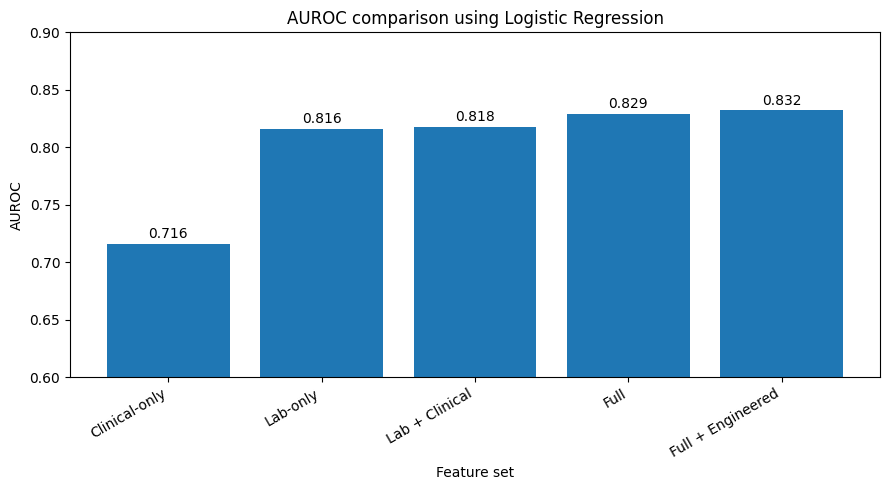

In [44]:
import matplotlib.pyplot as plt

# Filter Logistic Regression results only
lr_results = all_results_df_rounded[
    all_results_df_rounded['Model'] == 'Logistic Regression'
].copy()

# Sort in logical order
feature_order = [
    'Clinical-only',
    'Lab-only',
    'Lab + Clinical',
    'Full',
    'Full + Engineered'
]

lr_results['Feature_Set'] = pd.Categorical(
    lr_results['Feature_Set'],
    categories=feature_order,
    ordered=True
)

lr_results = lr_results.sort_values('Feature_Set')

# Plot AUROC
plt.figure(figsize=(9, 5))
plt.bar(lr_results['Feature_Set'], lr_results['AUROC_mean'])
plt.ylabel('AUROC')
plt.xlabel('Feature set')
plt.title('AUROC comparison using Logistic Regression')
plt.ylim(0.6, 0.9)
plt.xticks(rotation=30, ha='right')

for i, value in enumerate(lr_results['AUROC_mean']):
    plt.text(i, value + 0.005, str(value), ha='center')

plt.tight_layout()
plt.show()

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Prepare final X using Full + Engineered features
X_final = prepare_X(df_fe, features_full_fe)
y_final = df_fe['death'].copy()

# Train final Logistic Regression model on all data for interpretation
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

final_model.fit(X_final, y_final)

# Extract coefficients
coef = final_model.named_steps["model"].coef_[0]

coef_table = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': coef,
    'Abs_Coefficient': abs(coef)
}).sort_values(by='Abs_Coefficient', ascending=False)

coef_table.head(15)

,Feature,Coefficient,Abs_Coefficient
0,Age_years,0.741093,0.741093
1,Bilirubin,0.633673,0.633673
9,Prothrombin,0.502885,0.502885
5,Alk_Phos,0.431114,0.431114
12,High_Bilirubin,0.407281,0.407281
21,Ascites_Y,0.372547,0.372547
6,SGOT,0.343620,0.343620
10,Stage,0.235542,0.235542
13,Low_Albumin,-0.232465,0.232465
4,Copper,0.218976,0.218976


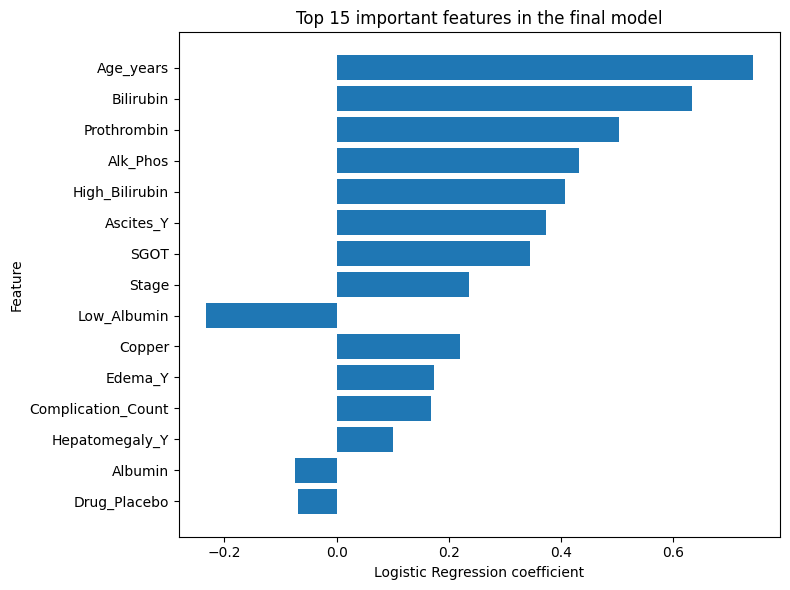

In [46]:
top_features = coef_table.head(15).sort_values(by='Abs_Coefficient')

plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel('Logistic Regression coefficient')
plt.ylabel('Feature')
plt.title('Top 15 important features in the final model')
plt.tight_layout()
plt.show()

In [47]:
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
import pandas as pd
import numpy as np

numeric_vars = [
    'Age_years',
    'Bilirubin',
    'Albumin',
    'Prothrombin',
    'Platelets',
    'Alk_Phos',
    'SGOT',
    'Stage',
    'Complication_Count'
]

categorical_vars = [
    'Sex',
    'Ascites',
    'Hepatomegaly',
    'Spiders',
    'Edema'
]

def median_iqr(series):
    series = series.dropna()
    median = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{median:.2f} ({q1:.2f}-{q3:.2f})"

table1_rows = []

# Numeric variables
for var in numeric_vars:
    group0 = df_fe[df_fe['death'] == 0][var].dropna()
    group1 = df_fe[df_fe['death'] == 1][var].dropna()

    try:
        p_value = mannwhitneyu(group0, group1, alternative='two-sided').pvalue
    except:
        p_value = np.nan

    table1_rows.append({
        'Variable': var,
        'Non-death / censored (death=0)': median_iqr(group0),
        'Death (death=1)': median_iqr(group1),
        'P_value': p_value
    })

# Categorical variables
for var in categorical_vars:
    temp = df_fe[[var, 'death']].copy()
    temp[var] = temp[var].fillna('Unknown')

    categories = temp[var].unique()

    contingency = pd.crosstab(temp[var], temp['death'])

    try:
        if contingency.shape == (2, 2):
            p_value = fisher_exact(contingency)[1]
        else:
            p_value = chi2_contingency(contingency)[1]
    except:
        p_value = np.nan

    for cat in categories:
        n0 = ((temp[var] == cat) & (temp['death'] == 0)).sum()
        d0 = (temp['death'] == 0).sum()
        pct0 = n0 / d0 * 100

        n1 = ((temp[var] == cat) & (temp['death'] == 1)).sum()
        d1 = (temp['death'] == 1).sum()
        pct1 = n1 / d1 * 100

        table1_rows.append({
            'Variable': f"{var} = {cat}",
            'Non-death / censored (death=0)': f"{n0} ({pct0:.1f}%)",
            'Death (death=1)': f"{n1} ({pct1:.1f}%)",
            'P_value': p_value
        })

table1 = pd.DataFrame(table1_rows)

table1['P_value'] = table1['P_value'].apply(
    lambda x: "<0.001" if pd.notnull(x) and x < 0.001 else round(x, 3) if pd.notnull(x) else ""
)

table1

,Variable,Non-death / censored (death=0),Death (death=1),P_value
0,Age_years,48.80 (40.80-56.40),53.50 (46.60-61.30),<0.001
1,Bilirubin,1.00 (0.70-1.80),3.20 (1.40-7.10),<0.001
2,Albumin,3.60 (3.35-3.82),3.40 (3.08-3.65),<0.001
3,Prothrombin,10.30 (9.90-10.80),11.00 (10.47-11.80),<0.001
4,Platelets,258.50 (209.00-318.00),224.00 (158.00-312.50),0.003
5,Alk_Phos,1132.00 (800.50-1648.50),1664.00 (1029.00-2468.00),<0.001
6,SGOT,98.00 (73.19-133.30),134.85 (99.33-176.70),<0.001
7,Stage,3.00 (2.00-3.00),4.00 (3.00-4.00),<0.001
8,Complication_Count,0.00 (0.00-1.00),1.00 (0.00-2.00),<0.001
9,Sex = F,237 (92.2%),137 (85.1%),0.032


In [48]:
# Save Table 1
table1.to_csv("Table1_baseline_characteristics.csv", index=False)

# Save model performance table
final_table.to_csv("Table2_model_performance.csv", index=False)

# Save feature importance table
coef_table.to_csv("Table3_feature_importance.csv", index=False)

print("Saved files:")
print("Table1_baseline_characteristics.csv")
print("Table2_model_performance.csv")
print("Table3_feature_importance.csv")

Saved files:
Table1_baseline_characteristics.csv
Table2_model_performance.csv
Table3_feature_importance.csv


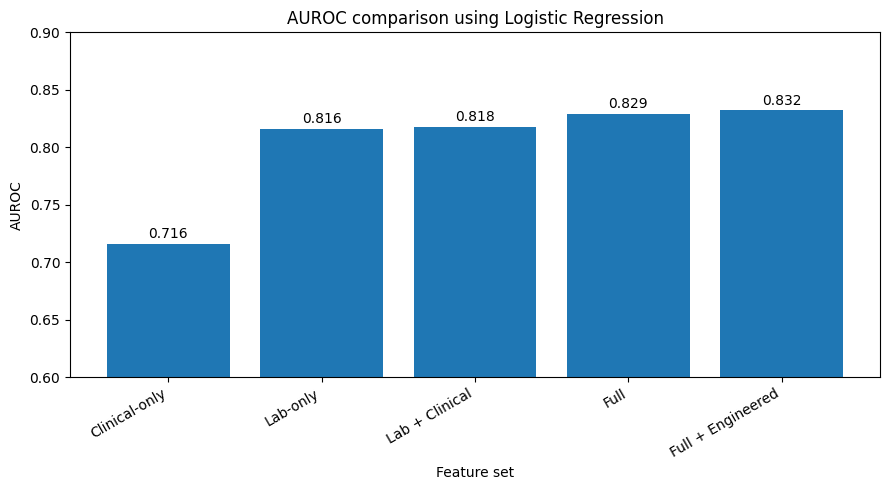

In [49]:
import matplotlib.pyplot as plt

lr_results = all_results_df_rounded[
    all_results_df_rounded['Model'] == 'Logistic Regression'
].copy()

feature_order = [
    'Clinical-only',
    'Lab-only',
    'Lab + Clinical',
    'Full',
    'Full + Engineered'
]

lr_results['Feature_Set'] = pd.Categorical(
    lr_results['Feature_Set'],
    categories=feature_order,
    ordered=True
)

lr_results = lr_results.sort_values('Feature_Set')

plt.figure(figsize=(9, 5))
plt.bar(lr_results['Feature_Set'], lr_results['AUROC_mean'])
plt.ylabel('AUROC')
plt.xlabel('Feature set')
plt.title('AUROC comparison using Logistic Regression')
plt.ylim(0.6, 0.9)
plt.xticks(rotation=30, ha='right')

for i, value in enumerate(lr_results['AUROC_mean']):
    plt.text(i, value + 0.005, str(value), ha='center')

plt.tight_layout()
plt.savefig("Figure1_AUROC_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

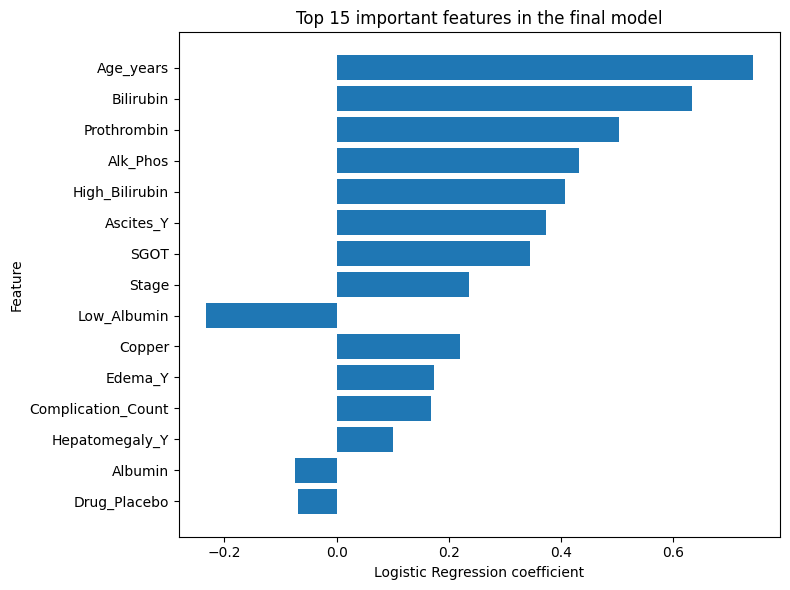

In [50]:
top_features = coef_table.head(15).sort_values(by='Abs_Coefficient')

plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel('Logistic Regression coefficient')
plt.ylabel('Feature')
plt.title('Top 15 important features in the final model')
plt.tight_layout()
plt.savefig("Figure2_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

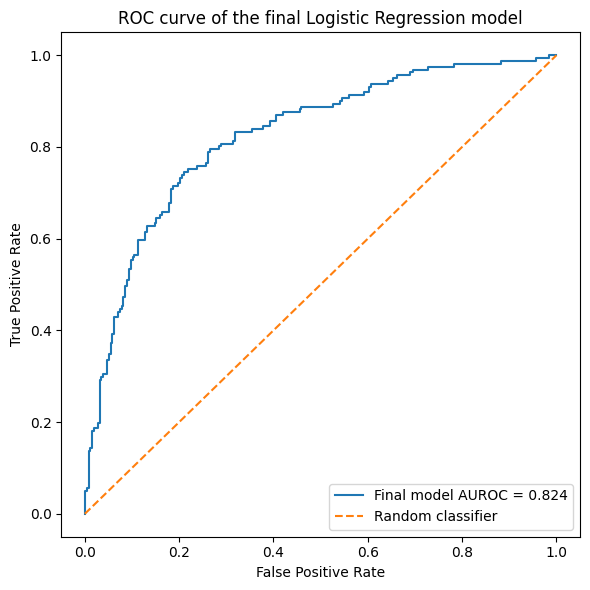

Saved: Figure3_ROC_curve_final_model.png


In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Final data
X_final = prepare_X(df_fe, features_full_fe)
y_final = df_fe['death'].copy()

# Final selected model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predicted probabilities
y_pred_prob = cross_val_predict(
    final_model,
    X_final,
    y_final,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_final, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Final model AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve of the final Logistic Regression model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("Figure3_ROC_curve_final_model.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure3_ROC_curve_final_model.png")

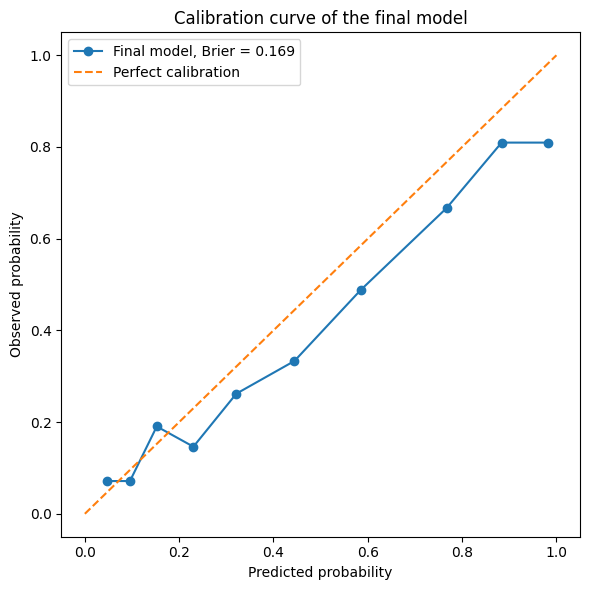

Saved: Figure4_calibration_curve_final_model.png
Brier score: 0.169


In [52]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# Prepare final data
X_final = prepare_X(df_fe, features_full_fe)
y_final = df_fe['death'].copy()

# Final selected model: Logistic Regression with Full + Engineered features
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predicted probabilities
y_pred_prob = cross_val_predict(
    final_model,
    X_final,
    y_final,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_final,
    y_pred_prob,
    n_bins=10,
    strategy="quantile"
)

# Brier score
brier = brier_score_loss(y_final, y_pred_prob)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=f"Final model, Brier = {brier:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration curve of the final model")
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("Figure4_calibration_curve_final_model.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure4_calibration_curve_final_model.png")
print("Brier score:", round(brier, 3))

<Figure size 600x500 with 0 Axes>

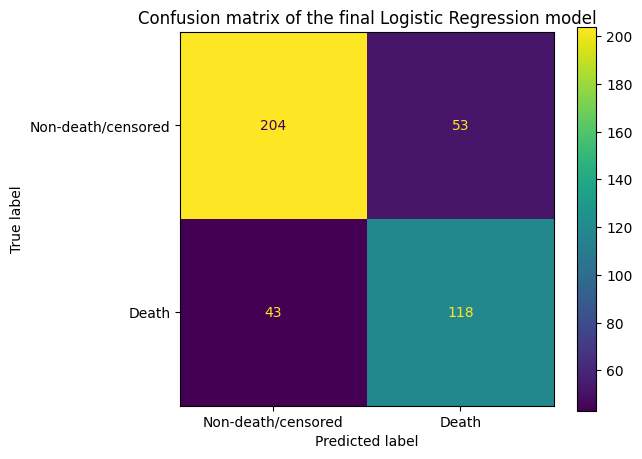

Saved: Figure5_confusion_matrix_final_model.png
[[204  53]
 [ 43 118]]


In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Prepare final data
X_final = prepare_X(df_fe, features_full_fe)
y_final = df_fe['death'].copy()

# Final selected model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predicted classes
y_pred = cross_val_predict(
    final_model,
    X_final,
    y_final,
    cv=cv,
    method="predict"
)

# Confusion matrix
cm = confusion_matrix(y_final, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-death/censored", "Death"]
)

plt.figure(figsize=(6, 5))
disp.plot(values_format="d", cmap=None)
plt.title("Confusion matrix of the final Logistic Regression model")
plt.tight_layout()
plt.savefig("Figure5_confusion_matrix_final_model.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure5_confusion_matrix_final_model.png")
print(cm)

/tmp/ipykernel_3671/2334598442.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['Non-death', 'Death'])
/tmp/ipykernel_3671/2334598442.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['Non-death', 'Death'])
/tmp/ipykernel_3671/2334598442.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['Non-death', 'Death'])
/tmp/ipykernel_3671/2334598442.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

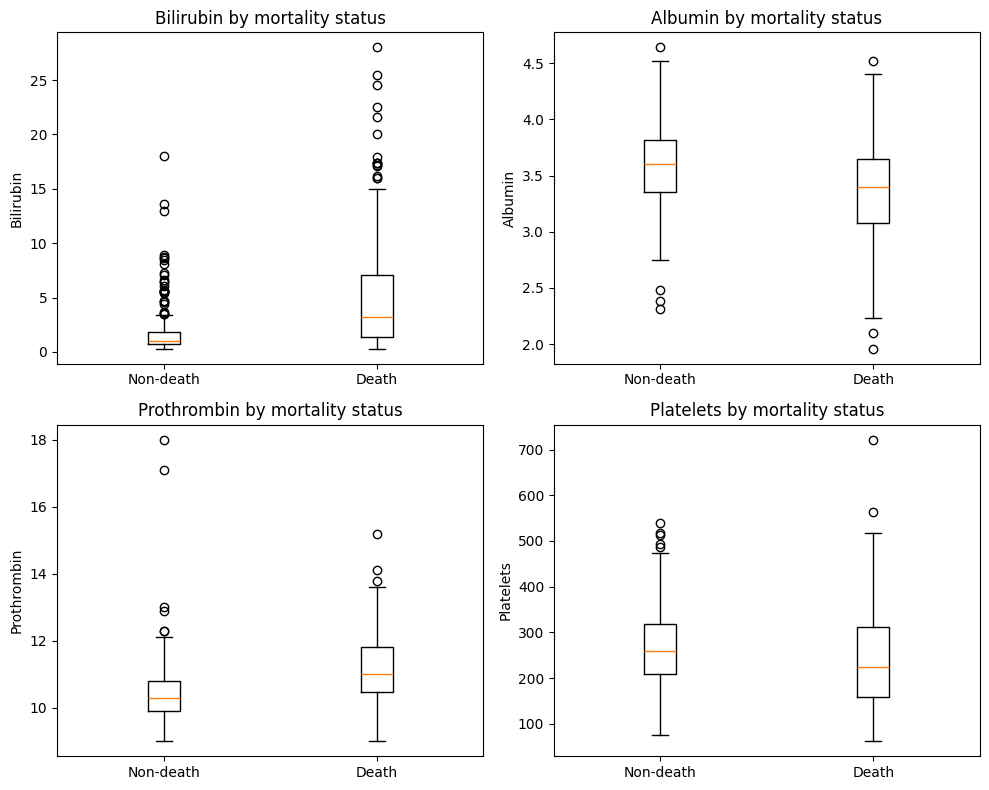

Saved: Figure6_laboratory_distributions_by_mortality.png


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 6: Key laboratory distributions by outcome

plot_vars = ['Bilirubin', 'Albumin', 'Prothrombin', 'Platelets']
titles = [
    'Bilirubin by mortality status',
    'Albumin by mortality status',
    'Prothrombin by mortality status',
    'Platelets by mortality status'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, var, title in zip(axes, plot_vars, titles):
    data0 = df_fe[df_fe['death'] == 0][var].dropna()
    data1 = df_fe[df_fe['death'] == 1][var].dropna()

    ax.boxplot([data0, data1], labels=['Non-death', 'Death'])
    ax.set_title(title)
    ax.set_ylabel(var)

plt.tight_layout()
plt.savefig("Figure6_laboratory_distributions_by_mortality.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure6_laboratory_distributions_by_mortality.png")

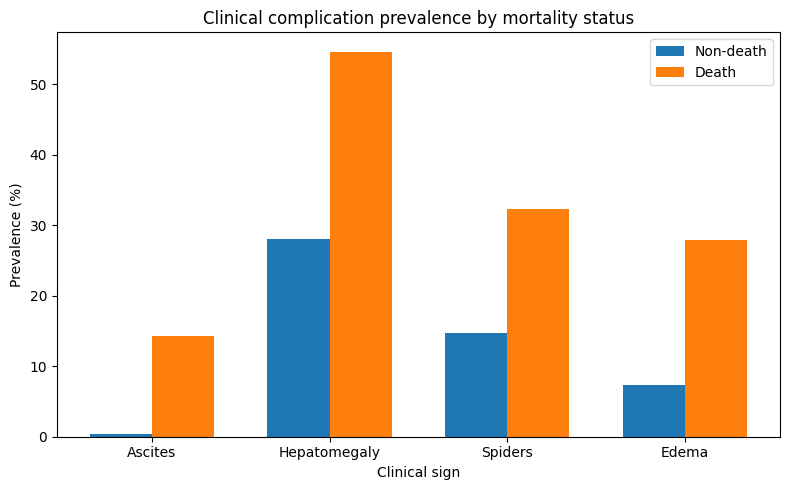

Saved: Figure7_clinical_complication_prevalence.png


In [55]:
# Figure 7: Clinical complication prevalence by outcome

clinical_binary = pd.DataFrame({
    'Ascites': np.where(df_fe['Ascites'] == 'Y', 1, 0),
    'Hepatomegaly': np.where(df_fe['Hepatomegaly'] == 'Y', 1, 0),
    'Spiders': np.where(df_fe['Spiders'] == 'Y', 1, 0),
    'Edema': np.where(df_fe['Edema'].isin(['S', 'Y']), 1, 0),
    'death': df_fe['death']
})

prevalence = clinical_binary.groupby('death').mean() * 100

features = ['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, prevalence.loc[0, features], width, label='Non-death')
plt.bar(x + width/2, prevalence.loc[1, features], width, label='Death')

plt.xticks(x, features)
plt.ylabel('Prevalence (%)')
plt.xlabel('Clinical sign')
plt.title('Clinical complication prevalence by mortality status')
plt.legend()
plt.tight_layout()

plt.savefig("Figure7_clinical_complication_prevalence.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure7_clinical_complication_prevalence.png")

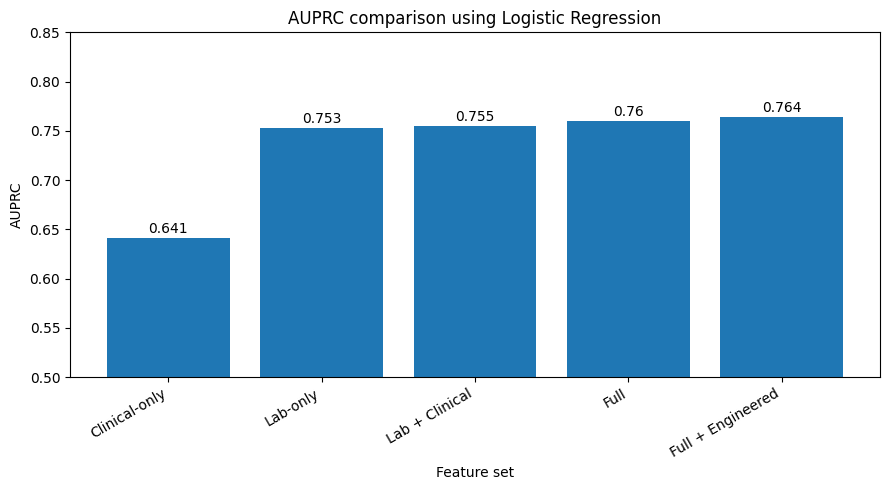

Saved: Figure8_AUPRC_comparison.png


In [56]:
# Figure 8: AUPRC comparison using Logistic Regression

lr_results = all_results_df_rounded[
    all_results_df_rounded['Model'] == 'Logistic Regression'
].copy()

feature_order = [
    'Clinical-only',
    'Lab-only',
    'Lab + Clinical',
    'Full',
    'Full + Engineered'
]

lr_results['Feature_Set'] = pd.Categorical(
    lr_results['Feature_Set'],
    categories=feature_order,
    ordered=True
)

lr_results = lr_results.sort_values('Feature_Set')

plt.figure(figsize=(9, 5))
plt.bar(lr_results['Feature_Set'], lr_results['AUPRC_mean'])
plt.ylabel('AUPRC')
plt.xlabel('Feature set')
plt.title('AUPRC comparison using Logistic Regression')
plt.ylim(0.5, 0.85)
plt.xticks(rotation=30, ha='right')

for i, value in enumerate(lr_results['AUPRC_mean']):
    plt.text(i, value + 0.005, str(value), ha='center')

plt.tight_layout()
plt.savefig("Figure8_AUPRC_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure8_AUPRC_comparison.png")

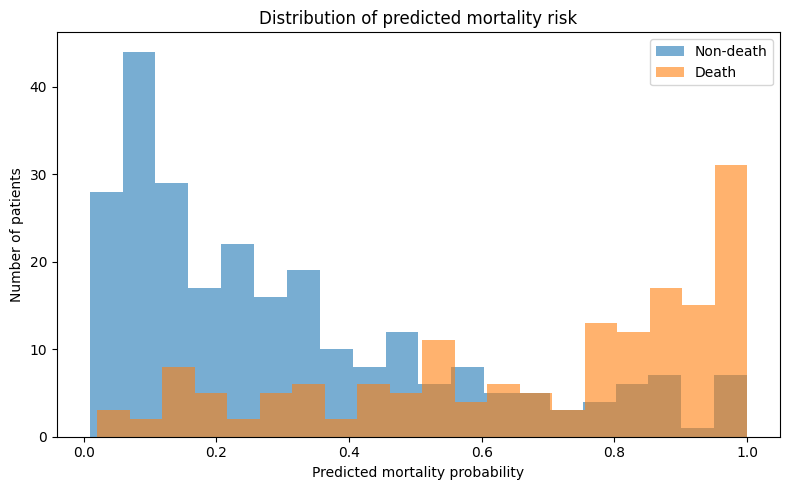

Saved: Figure9_predicted_risk_distribution.png


In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Prepare final model and data again
X_final = prepare_X(df_fe, features_full_fe)
y_final = df_fe['death'].copy()

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predicted probabilities
y_pred_prob = cross_val_predict(
    final_model,
    X_final,
    y_final,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Separate predicted risks
risk_non_death = y_pred_prob[y_final == 0]
risk_death = y_pred_prob[y_final == 1]

plt.figure(figsize=(8, 5))
plt.hist(risk_non_death, bins=20, alpha=0.6, label='Non-death')
plt.hist(risk_death, bins=20, alpha=0.6, label='Death')

plt.xlabel('Predicted mortality probability')
plt.ylabel('Number of patients')
plt.title('Distribution of predicted mortality risk')
plt.legend()
plt.tight_layout()

plt.savefig("Figure9_predicted_risk_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Figure9_predicted_risk_distribution.png")